In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
import plotly.express as px

In [207]:
from scipy.stats import f_oneway

In [10]:
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [18]:
pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   -----------------

In [27]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor

In [ ]:
pip install lightgbm

In [31]:
from sklearn.metrics import (
     classification_report, confusion_matrix, roc_auc_score,
     mean_absolute_error,mean_squared_error, r2_score, accuracy_score
)

In [37]:
import shap

In [ ]:
pip install shap

In [39]:
import datetime as dt

In [41]:
import scipy.optimize as opt
import itertools

In [45]:
import warnings
warnings.filterwarnings('ignore')

In [47]:
data = pd.read_csv(r'C:\Users\USER PC\Downloads\archive (7)\Flight_delay.csv')

In [49]:
data.head()

,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,4,03-01-2019,1829,1959,1925,WN,Southwest Airlines Co.,3920,N464WN,90,...,3,10,0,N,0,2,0,0,0,32
1,4,03-01-2019,1937,2037,1940,WN,Southwest Airlines Co.,509,N763SW,240,...,3,7,0,N,0,10,0,0,0,47
2,4,03-01-2019,1644,1845,1725,WN,Southwest Airlines Co.,1333,N334SW,121,...,6,8,0,N,0,8,0,0,0,72
3,4,03-01-2019,1452,1640,1625,WN,Southwest Airlines Co.,675,N286WN,228,...,7,8,0,N,0,3,0,0,0,12
4,4,03-01-2019,1323,1526,1510,WN,Southwest Airlines Co.,4,N674AA,123,...,4,9,0,N,0,0,0,0,0,16


### Checking data type and missing values

In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484551 entries, 0 to 484550
Data columns (total 29 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DayOfWeek          484551 non-null  int64 
 1   Date               484551 non-null  object
 2   DepTime            484551 non-null  int64 
 3   ArrTime            484551 non-null  int64 
 4   CRSArrTime         484551 non-null  int64 
 5   UniqueCarrier      484551 non-null  object
 6   Airline            484551 non-null  object
 7   FlightNum          484551 non-null  int64 
 8   TailNum            484551 non-null  object
 9   ActualElapsedTime  484551 non-null  int64 
 10  CRSElapsedTime     484551 non-null  int64 
 11  AirTime            484551 non-null  int64 
 12  ArrDelay           484551 non-null  int64 
 13  DepDelay           484551 non-null  int64 
 14  Origin             484551 non-null  object
 15  Org_Airport        483374 non-null  object
 16  Dest               4

In [58]:
data.isna().sum()

DayOfWeek               0
Date                    0
DepTime                 0
ArrTime                 0
CRSArrTime              0
UniqueCarrier           0
Airline                 0
FlightNum               0
TailNum                 0
ActualElapsedTime       0
CRSElapsedTime          0
AirTime                 0
ArrDelay                0
DepDelay                0
Origin                  0
Org_Airport          1177
Dest                    0
Dest_Airport         1479
Distance                0
TaxiIn                  0
TaxiOut                 0
Cancelled               0
CancellationCode        0
Diverted                0
CarrierDelay            0
WeatherDelay            0
NASDelay                0
SecurityDelay           0
LateAircraftDelay       0
dtype: int64

In [60]:
#Checking the % of missing values Org_Airport and Dest_Airport
data['Org_Airport'].isna().sum() , data['Dest_Airport'].isna().sum()

(1177, 1479)

In [70]:
(data['Org_Airport'].isna().mean() * 100,
 data['Dest_Airport'].isna().mean() * 100)

(0.24290528757550806, 0.3052310283128092)

In [72]:
#Dropping missing values
data=data.dropna(subset=['Org_Airport','Dest_Airport'])

In [74]:
data.isna().sum()

DayOfWeek            0
Date                 0
DepTime              0
ArrTime              0
CRSArrTime           0
UniqueCarrier        0
Airline              0
FlightNum            0
TailNum              0
ActualElapsedTime    0
CRSElapsedTime       0
AirTime              0
ArrDelay             0
DepDelay             0
Origin               0
Org_Airport          0
Dest                 0
Dest_Airport         0
Distance             0
TaxiIn               0
TaxiOut              0
Cancelled            0
CancellationCode     0
Diverted             0
CarrierDelay         0
WeatherDelay         0
NASDelay             0
SecurityDelay        0
LateAircraftDelay    0
dtype: int64

In [76]:
data.head()

,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,4,03-01-2019,1829,1959,1925,WN,Southwest Airlines Co.,3920,N464WN,90,...,3,10,0,N,0,2,0,0,0,32
1,4,03-01-2019,1937,2037,1940,WN,Southwest Airlines Co.,509,N763SW,240,...,3,7,0,N,0,10,0,0,0,47
2,4,03-01-2019,1644,1845,1725,WN,Southwest Airlines Co.,1333,N334SW,121,...,6,8,0,N,0,8,0,0,0,72
3,4,03-01-2019,1452,1640,1625,WN,Southwest Airlines Co.,675,N286WN,228,...,7,8,0,N,0,3,0,0,0,12
4,4,03-01-2019,1323,1526,1510,WN,Southwest Airlines Co.,4,N674AA,123,...,4,9,0,N,0,0,0,0,0,16


In [82]:
data.columns

Index(['DayOfWeek', 'Date', 'DepTime', 'ArrTime', 'CRSArrTime',
       'UniqueCarrier', 'Airline', 'FlightNum', 'TailNum', 'ActualElapsedTime',
       'CRSElapsedTime', 'AirTime', 'ArrDelay', 'DepDelay', 'Origin',
       'Org_Airport', 'Dest', 'Dest_Airport', 'Distance', 'TaxiIn', 'TaxiOut',
       'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay',
       'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay'],
      dtype='object')

In [96]:
delay_stat = data[['ArrDelay' , 'DepDelay']].describe()
delay_stat

,ArrDelay,DepDelay
count,481895.000000,481895.000000
mean,60.877770,57.463873
std,56.948971,55.959767
min,15.000000,6.000000
25%,25.000000,23.000000
50%,42.000000,40.000000
75%,76.000000,72.000000
max,1707.000000,1710.000000


### Flight Delay Distribution

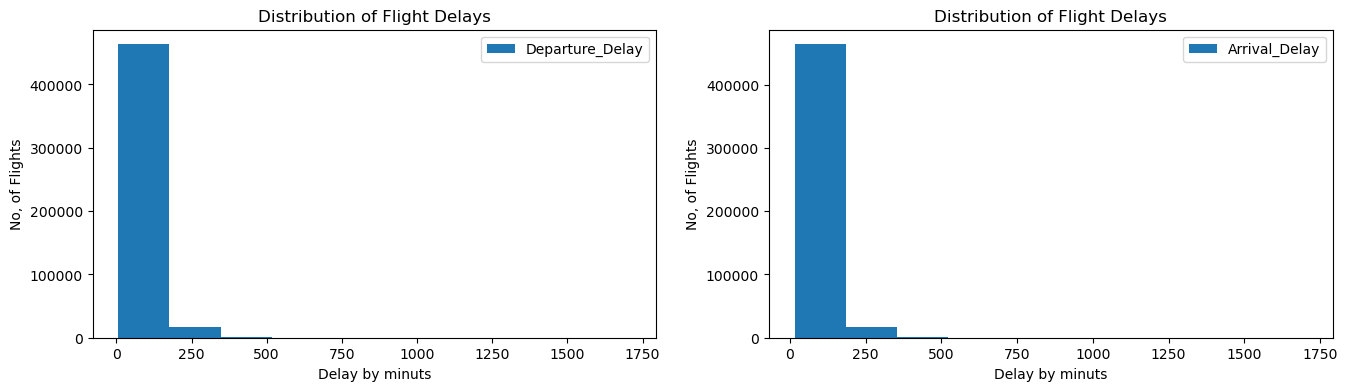

In [110]:
plt.figure(figsize = (16,4))
plt.subplot(1,2,1)

plt.hist(data['DepDelay'], label = 'Departure_Delay')
plt.title('Distribution of Flight Delays')
plt.xlabel('Delay by minuts')
plt.ylabel('No, of Flights')
plt.legend()

plt.subplot(1,2,2)

plt.hist(data['ArrDelay'], label = 'Arrival_Delay')
plt.title('Distribution of Flight Delays')
plt.xlabel('Delay by minuts')
plt.ylabel('No, of Flights')
plt.legend()
plt.show()

### Airline Delay Performance

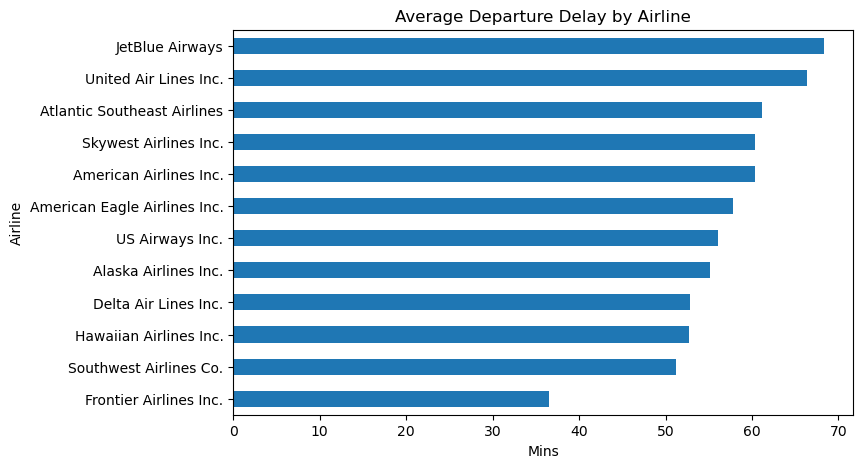

In [136]:
# Which airlines are the most or least puntual
delay_by_airline = data.groupby('Airline')['DepDelay'].mean().sort_values()
delay_by_airline.plot(kind='barh',figsize=(8,5))
plt.title('Average Departure Delay by Airline')
plt.xlabel('Mins')
plt.show()

### Delay by Day of Week

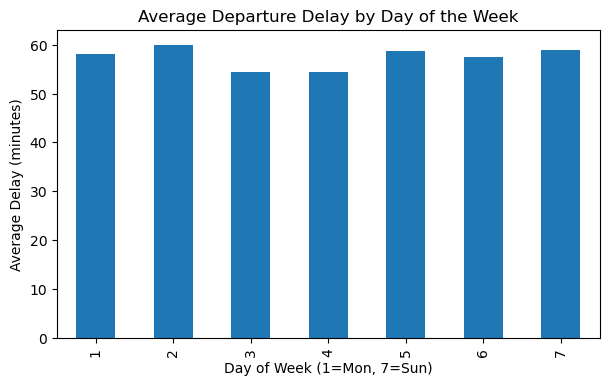

In [148]:
# Identify if the delays are worse on certains days
data.groupby('DayOfWeek')['DepDelay'].mean().plot(kind='bar',figsize=(7,4))
plt.title('Average Departure Delay by Day of the Week')
plt.xlabel('Day of Week (1=Mon, 7=Sun)')
plt.ylabel('Average Delay (minutes)')
plt.show()

### Delay by Hour of Day

In [151]:
# Extracting hours from scheduled time
data['DepHour'] = data['DepTime'] // 100

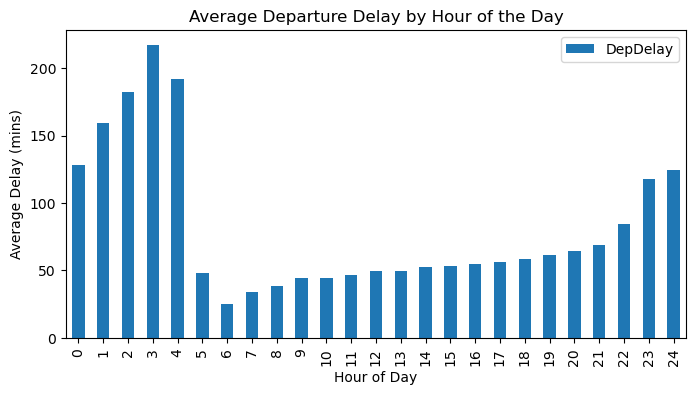

In [153]:
# Find out what time of day delays peak
data.groupby('DepHour')['DepDelay'].mean().plot(kind='bar',figsize=(8,4))
plt.title('Average Departure Delay by Hour of the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Delay (mins)')
plt.legend()
plt.show()

### Airport-Level delay Analysis

In [156]:
# Which airports have the highest avarage delays
data.groupby('Origin')['DepDelay'].mean().sort_values(ascending=False).head(10)
data.groupby('Dest')['ArrDelay'].mean().sort_values(ascending=False).head(10)

Dest
MQT    110.768116
ORD     81.505834
ACY     79.368421
EWR     78.409709
CRW     75.872180
YAK     74.987013
CEC     74.515152
JFK     74.001984
LNK     73.726974
CDV     73.236111
Name: ArrDelay, dtype: float64

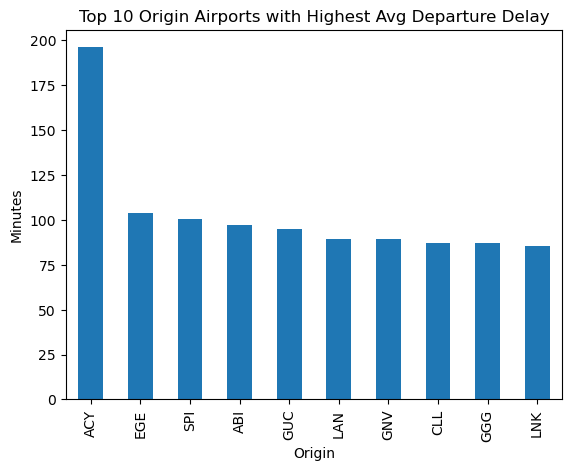

In [158]:
data.groupby('Origin')['DepDelay'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Origin Airports with Highest Avg Departure Delay')
plt.ylabel('Minutes')
plt.show()

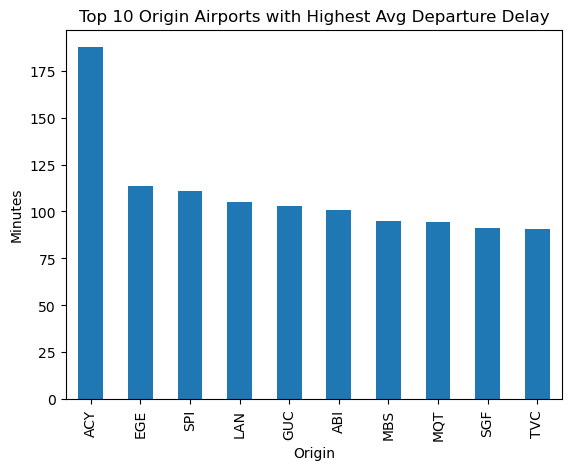

In [160]:
data.groupby('Origin')['ArrDelay'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Origin Airports with Highest Avg Departure Delay')
plt.ylabel('Minutes')
plt.show()

### Correlation Between Departure and Arrival Delays

Correlation between departure and arrival delay:0.95


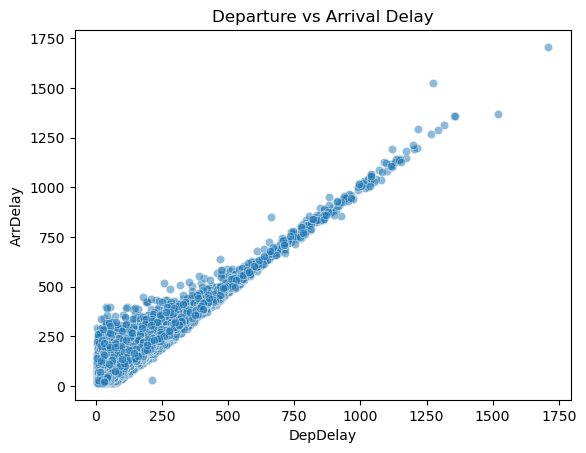

In [175]:
# How storngly late departure lead to late arrivals
corr = data[['DepDelay' , 'ArrDelay']].corr().iloc[0,1]
print(f'Correlation between departure and arrival delay:{corr:.2f}')
sns.scatterplot(x='DepDelay' , y='ArrDelay', data=data, alpha=0.5)
plt.title('Departure vs Arrival Delay')
plt.show()

### Delay vs Flight Distance

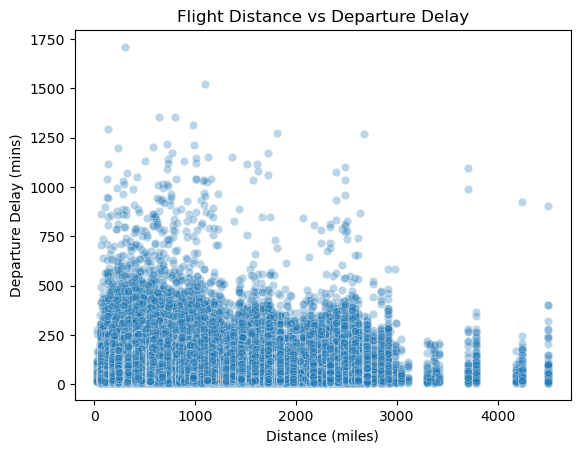

In [182]:
#Check if longer routes face longer delays
sns.scatterplot(x='Distance',y='DepDelay', data=data, alpha=0.3)
plt.title('Flight Distance vs Departure Delay')
plt.xlabel('Distance (miles)')
plt.ylabel('Departure Delay (mins)')
plt.show()

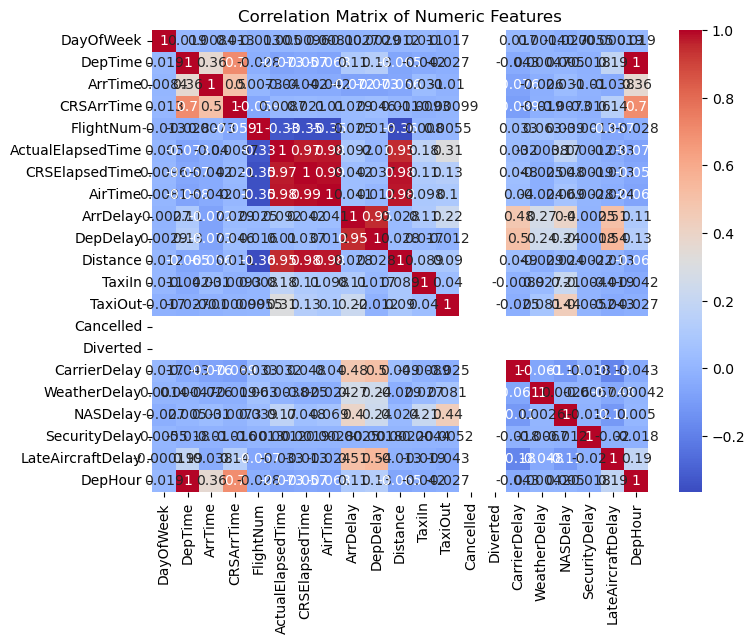

In [186]:
#Correlation Matrix of Numeric Features
corr = data.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [190]:
#Average Delays per Airline
data.groupby('Airline')['DepDelay'].mean().sort_values(ascending=False)

Airline
JetBlue Airways                 68.284822
United Air Lines Inc.           66.369007
Atlantic Southeast Airlines     61.176082
Skywest Airlines Inc.           60.324096
American Airlines Inc.          60.314908
American Eagle Airlines Inc.    57.815241
US Airways Inc.                 56.025004
Alaska Airlines Inc.            55.162000
Delta Air Lines Inc.            52.862541
Hawaiian Airlines Inc.          52.752083
Southwest Airlines Co.          51.245128
Frontier Airlines Inc.          36.504382
Name: DepDelay, dtype: float64

In [194]:
#Average Delays per Day of the Week
#Note that ! = Monday while 7 = Sunday
data.groupby('DayOfWeek')['DepDelay'].mean().sort_values(ascending=False)

DayOfWeek
2    60.041913
7    58.901801
5    58.756149
1    58.003064
6    57.489434
3    54.432597
4    54.347629
Name: DepDelay, dtype: float64

In [198]:
#Arrival Delay rate per Origin Airport
data.groupby('Org_Airport')['ArrDelay'].mean().sort_values(ascending=False)

Org_Airport
Atlantic City International Airport                             187.500000
Eagle County Regional Airport                                   113.590406
Abraham Lincoln Capital Airport                                 111.090909
Capital Region International Airport ( Lansing Capital City)    105.020833
Gunnison-Crested Butte Regional Airport                         103.075949
                                                                   ...    
Ralph Wien Memorial Airport                                      45.176471
Oakland International Airport                                    44.797799
McClellan-Palomar Airport                                        43.157895
Hilo International Airport                                       41.187500
Westerly State Airport                                           21.000000
Name: ArrDelay, Length: 259, dtype: float64

In [200]:
#Departure Delay rate per Origin Airport
data.groupby('Org_Airport')['DepDelay'].mean().sort_values(ascending=False)

Org_Airport
Atlantic City International Airport               195.800000
Eagle County Regional Airport                     103.568266
Abraham Lincoln Capital Airport                   100.254545
Abilene Regional Airport                           96.821656
Gunnison-Crested Butte Regional Airport            95.088608
                                                     ...    
Grand Junction Regional Airport (Walker Field)     44.492063
Lihue Airport                                      44.226054
Hilo International Airport                         38.812500
McClellan-Palomar Airport                          36.572368
Westerly State Airport                             18.000000
Name: DepDelay, Length: 259, dtype: float64

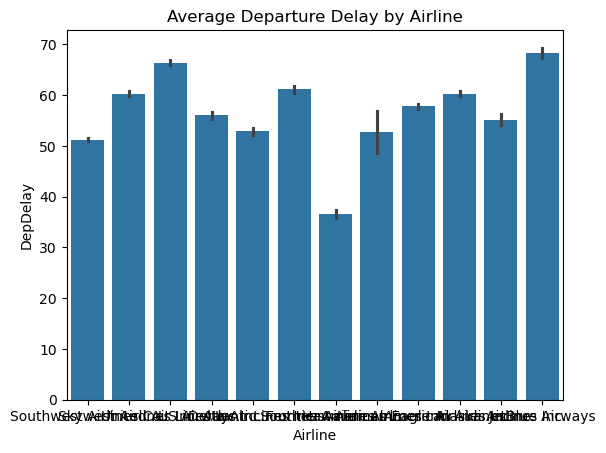

In [202]:
#Delay by Airline
sns.barplot(x='Airline' , y='DepDelay' , data=data, estimator='mean')
plt.title('Average Departure Delay by Airline')
plt.show()

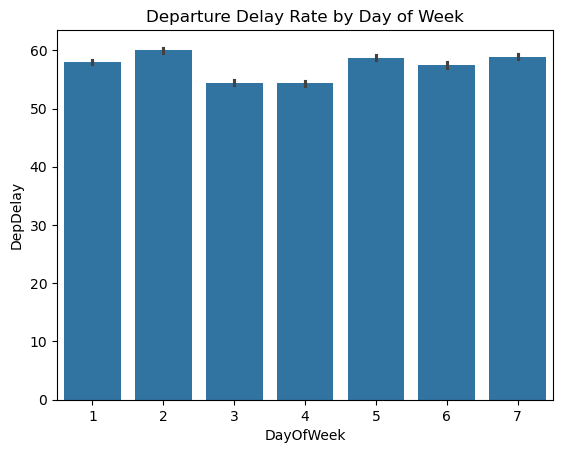

In [204]:
# Depature Delay Rate by Day of Week
sns.barplot(x='DayOfWeek' , y='DepDelay', data=data, estimator='mean')
plt.title('Departure Delay Rate by Day of Week')
plt.show()

### Predictive Analysis

In [214]:
#Predicting if a Flight will be Delayed
data['Delayed'] = (data['DepDelay'] > 15).astype(int)
data['Delayed']

0         1
1         1
2         1
3         1
4         1
         ..
484546    1
484547    1
484548    1
484549    1
484550    1
Name: Delayed, Length: 481895, dtype: int32

In [220]:
target = 'DepDelay'
features = ['Airline' , 'DayOfWeek' , 'Org_Airport' , 'Dest_Airport' , 'Distance']
y=data[features]
x=data[target]

In [222]:
data[features + [target]].info()

<class 'pandas.core.frame.DataFrame'>
Index: 481895 entries, 0 to 484550
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Airline       481895 non-null  object
 1   DayOfWeek     481895 non-null  int64 
 2   Org_Airport   481895 non-null  object
 3   Dest_Airport  481895 non-null  object
 4   Distance      481895 non-null  int64 
 5   DepDelay      481895 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 25.7+ MB


In [226]:
data.head(2)

,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,...,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,DepHour,Delayed
0,4,03-01-2019,1829,1959,1925,WN,Southwest Airlines Co.,3920,N464WN,90,...,0,N,0,2,0,0,0,32,18,1
1,4,03-01-2019,1937,2037,1940,WN,Southwest Airlines Co.,509,N763SW,240,...,0,N,0,10,0,0,0,47,19,1


In [232]:
data.columns

Index(['DayOfWeek', 'Date', 'DepTime', 'ArrTime', 'CRSArrTime',
       'UniqueCarrier', 'Airline', 'FlightNum', 'TailNum', 'ActualElapsedTime',
       'CRSElapsedTime', 'AirTime', 'ArrDelay', 'DepDelay', 'Origin',
       'Org_Airport', 'Dest', 'Dest_Airport', 'Distance', 'TaxiIn', 'TaxiOut',
       'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay',
       'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay',
       'DepHour', 'Delayed'],
      dtype='object')

In [254]:
x.head()

0    34
1    67
2    94
3    27
4    28
Name: DepDelay, dtype: int64

In [256]:
y.head()

,Airline,DayOfWeek,Org_Airport,Dest_Airport,Distance
0,Southwest Airlines Co.,4,Indianapolis International Airport,Baltimore-Washington International Airport,515
1,Southwest Airlines Co.,4,Indianapolis International Airport,McCarran International Airport,1591
2,Southwest Airlines Co.,4,Indianapolis International Airport,Orlando International Airport,828
3,Southwest Airlines Co.,4,Indianapolis International Airport,Phoenix Sky Harbor International Airport,1489
4,Southwest Airlines Co.,4,Indianapolis International Airport,Tampa International Airport,838


In [258]:
x.head()
y.head()

,Airline,DayOfWeek,Org_Airport,Dest_Airport,Distance
0,Southwest Airlines Co.,4,Indianapolis International Airport,Baltimore-Washington International Airport,515
1,Southwest Airlines Co.,4,Indianapolis International Airport,McCarran International Airport,1591
2,Southwest Airlines Co.,4,Indianapolis International Airport,Orlando International Airport,828
3,Southwest Airlines Co.,4,Indianapolis International Airport,Phoenix Sky Harbor International Airport,1489
4,Southwest Airlines Co.,4,Indianapolis International Airport,Tampa International Airport,838


In [274]:
data.columns

Index(['DayOfWeek', 'Date', 'DepTime', 'ArrTime', 'CRSArrTime',
       'UniqueCarrier', 'Airline', 'FlightNum', 'TailNum', 'ActualElapsedTime',
       'CRSElapsedTime', 'AirTime', 'ArrDelay', 'DepDelay', 'Origin',
       'Org_Airport', 'Dest', 'Dest_Airport', 'Distance', 'TaxiIn', 'TaxiOut',
       'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay',
       'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay',
       'DepHour', 'Delayed'],
      dtype='object')

In [278]:
data.head()

,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,...,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,DepHour,Delayed
0,4,03-01-2019,1829,1959,1925,WN,Southwest Airlines Co.,3920,N464WN,90,...,0,N,0,2,0,0,0,32,18,1
1,4,03-01-2019,1937,2037,1940,WN,Southwest Airlines Co.,509,N763SW,240,...,0,N,0,10,0,0,0,47,19,1
2,4,03-01-2019,1644,1845,1725,WN,Southwest Airlines Co.,1333,N334SW,121,...,0,N,0,8,0,0,0,72,16,1
3,4,03-01-2019,1452,1640,1625,WN,Southwest Airlines Co.,675,N286WN,228,...,0,N,0,3,0,0,0,12,14,1
4,4,03-01-2019,1323,1526,1510,WN,Southwest Airlines Co.,4,N674AA,123,...,0,N,0,0,0,0,0,16,13,1


In [288]:
#Daily Average
daily_delay = data.groupby('Date')['DepDelay'].mean().reset_index()
daily_delay

,Date,DepDelay
0,01-01-2019,60.329867
1,01-02-2019,67.823184
2,01-03-2019,52.045959
3,01-04-2019,54.505644
4,01-05-2019,49.434082
...,...,...
176,30-05-2019,61.619387
177,30-06-2019,49.788241
178,31-01-2019,70.756546
179,31-03-2019,62.912954


In [298]:
#Checking my Date data type
data['Date'].head()
data['Date'].dtype

dtype('O')

In [302]:
#Changing from object type to datetime
data['Date'] = pd.to_datetime(data['Date'], errors='coerce', infer_datetime_format=True)

In [304]:
data['Date'].dtype

dtype('<M8[ns]')

In [314]:
#Dropping NA from Date because of "'NaTType' of'start_time'"
data = data.dropna(subset=['Date'])

In [316]:
#Weekly Average
data['Week'] = data['Date'].dt.to_period('W').apply(lambda r: r.start_time)
weekly_delay = (
    data.groupby('Week')['DepDelay']
    .mean()
    .reset_index()
)

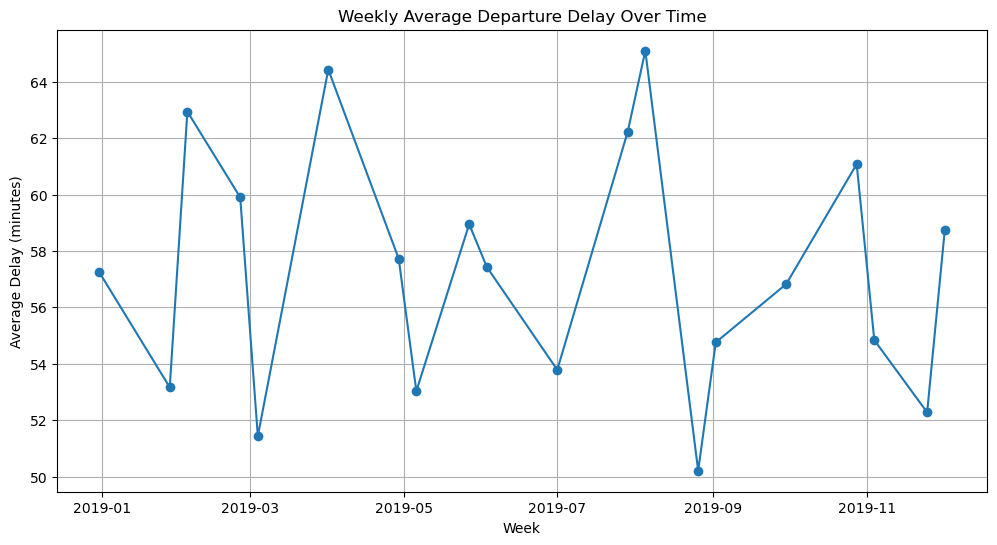

In [326]:
plt.figure(figsize=(12,6))
plt.plot(weekly_delay['Week'], weekly_delay['DepDelay'], marker='o')
plt.title("Weekly Average Departure Delay Over Time")
plt.xlabel("Week")
plt.ylabel("Average Delay (minutes)")
plt.grid(True)
plt.show()

In [330]:
daily_counts = (
    data.groupby(['Date','Org_Airport'])
    .size()
    .reset_index(name='FlightNum')
)
daily_counts

,Date,Org_Airport,FlightNum
0,2019-01-01,Akron-Canton Regional Airport,4
1,2019-01-01,Albany International Airport,10
2,2019-01-01,Albuquerque International Sunport,14
3,2019-01-01,Appleton International Airport,2
4,2019-01-01,Aspen-Pitkin County Airport,16
...,...,...,...
12976,2019-12-06,Wilkes-Barre/Scranton International Airport,2
12977,2019-12-06,Will Rogers World Airport,12
12978,2019-12-06,William P. Hobby Airport,36
12979,2019-12-06,Wilmington International Airport,1


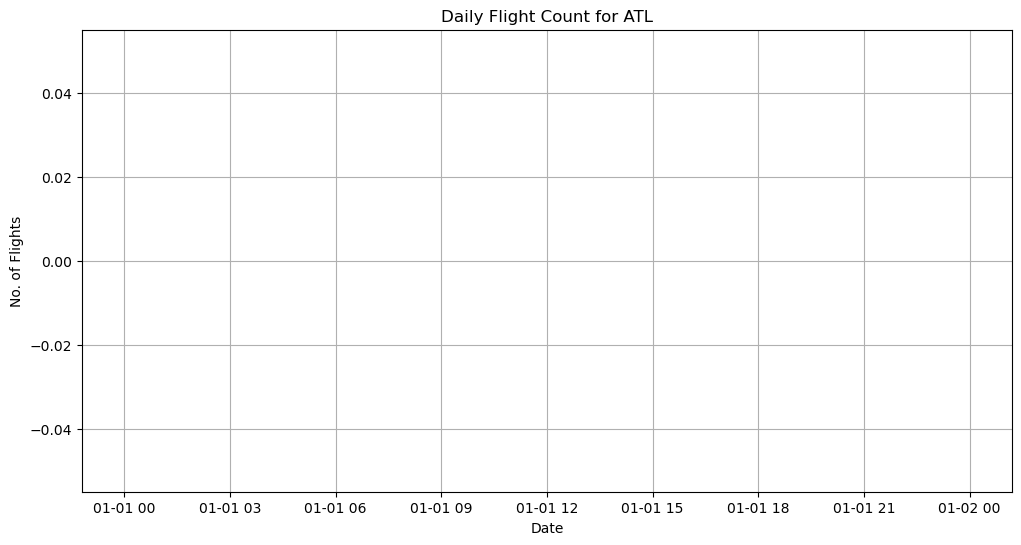

In [336]:
airport = 'ATL'
airport_data = daily_counts[daily_counts['Org_Airport'] == airport]
plt.figure(figsize=(12,6))
plt.plot(airport_data['Date'],airport_data['FlightNum'], marker='o')
plt.title(f'Daily Flight Count for {airport}')
plt.xlabel('Date')
plt.ylabel('No. of Flights')
plt.grid(True)
plt.show()

### Estimate Flight Congestion Likelihood for Route

In [341]:
# Flight-level if delayed > 15 mins
data['IsDelayed'] = (data['DepDelay'] > 15).astype(int)

# Route ID
data['Route'] = data['Org_Airport'].str.strip().str.upper()+'_'+data['Dest_Airport'].str.strip().str.upper()

In [343]:
route_day = (
    data.groupby(['Route','Date'])
        .agg(total_flights=('Route','size'),
             delayed_flights=('IsDelayed','sum'))
    .reset_index()
)
route_day['delayed_rate'] = route_day['delayed_flights']/route_day['total_flights']
route_day['Route_Conge'] = (route_day['delayed_rate']>0.30).astype(int)

In [345]:
route_day

,Route,Date,total_flights,delayed_flights,delayed_rate,Route_Conge
0,ABILENE REGIONAL AIRPORT_DALLAS/FORT WORTH INT...,2019-01-03,3,3,1.0,1
1,ABILENE REGIONAL AIRPORT_DALLAS/FORT WORTH INT...,2019-02-01,3,3,1.0,1
2,ABILENE REGIONAL AIRPORT_DALLAS/FORT WORTH INT...,2019-02-02,1,1,1.0,1
3,ABILENE REGIONAL AIRPORT_DALLAS/FORT WORTH INT...,2019-03-01,1,0,0.0,0
4,ABILENE REGIONAL AIRPORT_DALLAS/FORT WORTH INT...,2019-03-03,1,0,0.0,0
...,...,...,...,...,...,...
98400,YUMA INTERNATIONAL AIRPORT_SALT LAKE CITY INTE...,2019-07-02,2,1,0.5,1
98401,YUMA INTERNATIONAL AIRPORT_SALT LAKE CITY INTE...,2019-09-02,1,1,1.0,1
98402,YUMA INTERNATIONAL AIRPORT_SALT LAKE CITY INTE...,2019-09-03,1,1,1.0,1
98403,YUMA INTERNATIONAL AIRPORT_SALT LAKE CITY INTE...,2019-10-01,1,0,0.0,0


In [349]:
route_stats = route_day.groupby('Route')['delayed_rate'].agg(['mean','median','count']).sort_values('mean',ascending=False)
route_stats.head(20)

,mean,median,count
Route,,,
DALLAS/FORT WORTH INTERNATIONAL AIRPORT_JACKSON HOLE AIRPORT,1.0,1.0,9
PORT COLUMBUS INTERNATIONAL AIRPORT_PHILADELPHIA INTERNATIONAL AIRPORT,1.0,1.0,31
DALLAS/FORT WORTH INTERNATIONAL AIRPORT_BLUE GRASS AIRPORT,1.0,1.0,23
PORT COLUMBUS INTERNATIONAL AIRPORT_LOS ANGELES INTERNATIONAL AIRPORT,1.0,1.0,1
DALLAS/FORT WORTH INTERNATIONAL AIRPORT_BUFFALO NIAGARA INTERNATIONAL AIRPORT,1.0,1.0,6
PORT COLUMBUS INTERNATIONAL AIRPORT_JOHN F. KENNEDY INTERNATIONAL AIRPORT (NEW YORK INTERNATIONAL AIRPORT),1.0,1.0,2
PORT COLUMBUS INTERNATIONAL AIRPORT_DENVER INTERNATIONAL AIRPORT,1.0,1.0,17
PORT COLUMBUS INTERNATIONAL AIRPORT_CINCINNATI/NORTHERN KENTUCKY INTERNATIONAL AIRPORT,1.0,1.0,5
PITTSBURGH INTERNATIONAL AIRPORT_TAMPA INTERNATIONAL AIRPORT,1.0,1.0,23


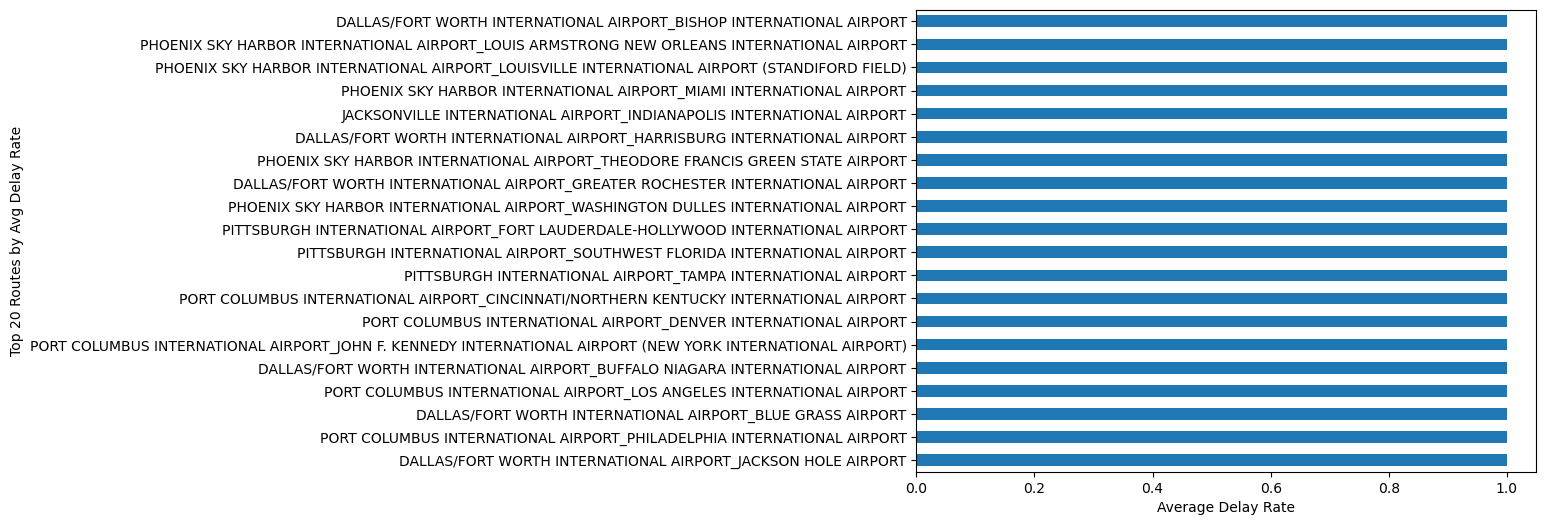

In [353]:
route_stats['mean'].head(20).plot(kind='barh',figsize=(8,6))
plt.xlabel('Average Delay Rate')
plt.ylabel('Top 20 Routes by Avg Delay Rate')
plt.show()

### Optimization

In [357]:
airport_delay = data.groupby('Org_Airport')['ArrDelay'].mean().sort_values(ascending=False)
airport_delay.head(10)

Org_Airport
Eagle County Regional Airport              137.304688
Atlantic City International Airport        133.500000
Gunnison-Crested Butte Regional Airport    133.075000
East Texas Regional Airport                115.250000
Sawyer International Airport               109.333333
University Park Airport                    105.100000
Bellingham International Airport           102.000000
Cherry Capital Airport                     100.009901
Abraham Lincoln Capital Airport             99.840000
Pocatello Regional Airport                  97.444444
Name: ArrDelay, dtype: float64

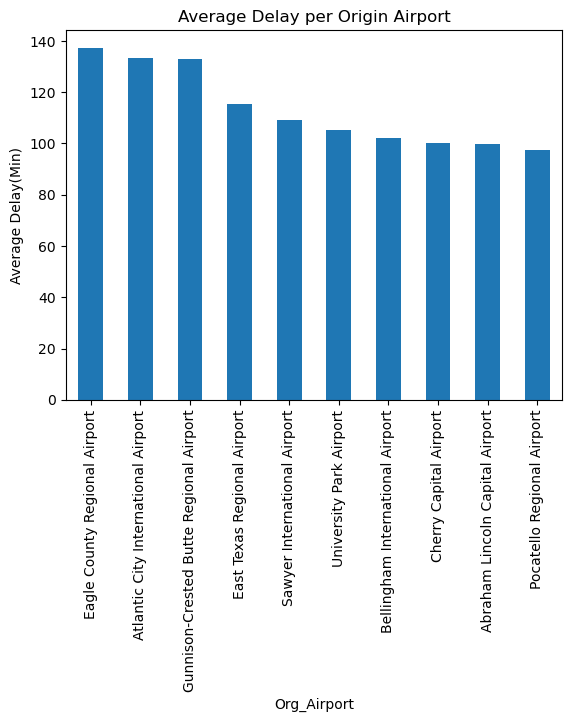

In [360]:
airport_delay.head(10).plot(kind='bar')
plt.title('Average Delay per Origin Airport')
plt.ylabel('Average Delay(Min)')
plt.show()

In [362]:
data.head(2)

,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,...,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,DepHour,Delayed,Week,IsDelayed,Route
0,4,2019-03-01,1829,1959,1925,WN,Southwest Airlines Co.,3920,N464WN,90,...,2,0,0,0,32,18,1,2019-02-25,1,INDIANAPOLIS INTERNATIONAL AIRPORT_BALTIMORE-W...
1,4,2019-03-01,1937,2037,1940,WN,Southwest Airlines Co.,509,N763SW,240,...,10,0,0,0,47,19,1,2019-02-25,1,INDIANAPOLIS INTERNATIONAL AIRPORT_MCCARRAN IN...


In [372]:
data.columns

Index(['DayOfWeek', 'Date', 'DepTime', 'ArrTime', 'CRSArrTime',
       'UniqueCarrier', 'Airline', 'FlightNum', 'TailNum', 'ActualElapsedTime',
       'CRSElapsedTime', 'AirTime', 'ArrDelay', 'DepDelay', 'Origin',
       'Org_Airport', 'Dest', 'Dest_Airport', 'Distance', 'TaxiIn', 'TaxiOut',
       'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay',
       'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay',
       'DepHour', 'Delayed', 'Week', 'IsDelayed', 'Route'],
      dtype='object')